# Piety Analysis

The Piety system in Fantasy Wargaming is bewilderingly complex.

There are piety points, piety bands, and a complicated-looking table with step sizes for moving forward (e.g., pious person doing virtuous things) and distinct steps sizes for moving backwards (e.g., previously pious person sinning.)

We'll look at Piety Bands and the complicated Piety Changes table.

## Piety Points to Piety Band

See FW page 227 for Piety Band. Definition.

    Piety points 0-09 = Piety band or PB 0.
    Piety points 10-39 = Piety band or PB 1.
    Piety points 40-79 = Piety band or PB 2.
    Piety points 80-129 = Piety band or PB 3.
    Piety points 130-189 = Piety band or PB 4.
    Piety points 190-259 = Piety band or PB 5.

    Etc.—width of band increasing by 10 each time.

This is a polynomial. Piety, $P$, from band, $B$ is this.

$$
P = 5B^2 + 15B - 10
$$

In [146]:
from sympy.abc import x, y
from sympy import solve, symbols

In [147]:
solve(y - (5*x**2 + 15*x - 10), x)

[-sqrt(20*y + 425)/10 - 3/2, sqrt(20*y + 425)/10 - 3/2]

The inverse, computing band, $B$, from a Piety level, $P$ is this.

$$
B = \frac{\sqrt{20 P + 425}}{10} - \frac{3}{2}
$$

Compare this with the measures table used in OpenD6.
The exponential growth is distinct from the FW polynomial growth.

$$
B = 5 \log_{10}{P}
$$

In [148]:
from sympy import sqrt, Function, ln, log, exp, symbols

P = symbols("P")
B_P = Function('B_P')
B_P = sqrt(20*P + 425)/10 - 3/2

# More typical of OpenD6
M_P = 5 * log(P, 10)

In [149]:
print("FW Band", "|", "OpenD6 value")
print("-------", "|", "------" )
for y_val in (10, 40, 80, 130, 190, 260, 340):
    print(B_P.evalf(subs={P: y_val}), "|", M_P.evalf(subs={P: y_val}))

FW Band | OpenD6 value
------- | ------
1.00000000000000 | 5.00000000000000
2.00000000000000 | 8.01029995663981
3.00000000000000 | 9.51544993495972
4.00000000000000 | 10.5697167615342
5.00000000000000 | 11.3937680047641
6.00000000000000 | 12.0748667398541
7.00000000000000 | 12.6573945852113


## Piety Changes

The Piety changes are detailed in a table on page 228.
The size of a change depends on the character's current Piety Band and the Magnitude of the event (either a sin or a virtue.)

$$
\Delta P = f(B, M)
$$

Event magnitudes, $M$, are on a 1-7 scale, with 1 being significant, and 7 being minor. There's a clear relationship $\Delta P \varpropto \frac{1}{M}$.

Less clear is the relationship to the band, $B$. This is also a relationship with piety, $P$, because $B = \frac{\sqrt{20 P + 425}}{10} - \frac{3}{2}$. However, the relationships are more clear if we use the band, $B$.

The rules distinguish between four cases.

1.  Pious Characters.

    a. Yet more pious acts.

    b. Some unexpected sinful act.

2.  Impious characters.

    a. Sinning yet again.

    b. Some unexected virtuous act.

These are mirror images.
Cases 1a and 2a are a character acting in accordance with expectations. These have small $\Delta P$ values.
Cases 1b and 2b are a character behaving improperly. These will have large $\Delta P$ values.

A graph shows the three sub-ranges: -7 to -1, 0, and 1 to 7.

In [150]:
import matplotlib.pyplot as plt

In [151]:
band = [
    -7, -6, -5, -4, -3, -2, -1,
    0,
    1, 2, 3, 4, 5, 6, 7
]

In [152]:
delta = [
    8.5, 10, 11, 12.5, 13.5, 15, 17.5,
    21.5,
    25, 35, 45, 55, 65, 75, 85
]

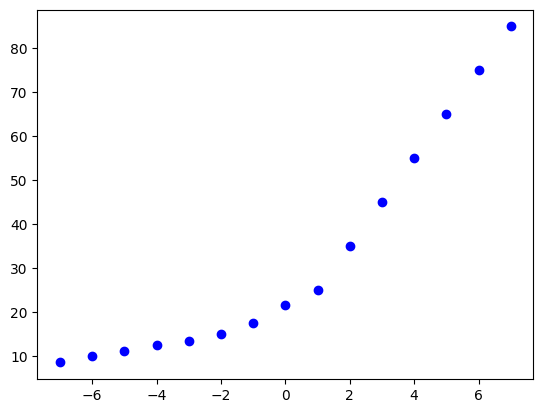

In [153]:
plt.plot(band, delta, 'bo', label='data')

We can break this into two halves: below zero and above zero.
The below zero is almost linear.

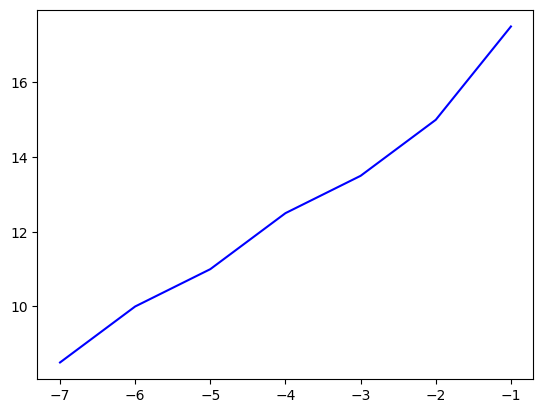

In [154]:
plt.plot(band[:7], delta[:7], 'b-', label='lower')

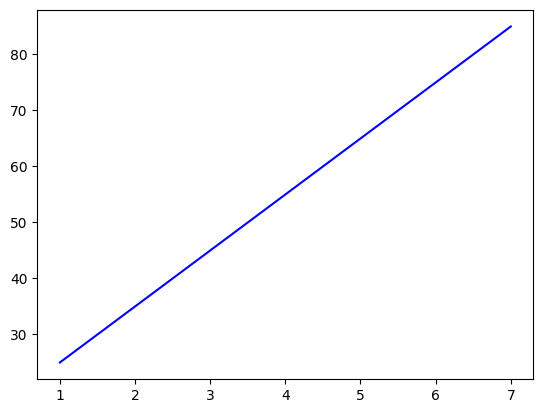

In [155]:
plt.plot(band[8:], delta[8:], 'b-', label='upper')

In [156]:
from statistics import correlation, linear_regression

The below zero scrtion applies when the action's piety aigns with the character's current status. The line is a pretty close fit to the published numbers.

In [157]:
correlation(band[:7], delta[:7])

0.9912240861262788

In [158]:
linear_regression(band[:7], delta[:7])

LinearRegression(slope=1.4107142857142858, intercept=18.214285714285715)

The above zero portion applies when the action's piety is opposed to the character's current status. The published data are obviously linear.

In [159]:
correlation(band[8:], delta[8:])

1.0

In [160]:
linear_regression(band[8:], delta[8:])

LinearRegression(slope=10.0, intercept=15.0)

## Computing $\Delta P$ from Band, $B$

In [126]:
def delta_P(band: int, magnitude: int):
    if band < 0:
        delta_1 = band * 1.4 + 18
    elif band > 0:
        delta_1 = band * 10 + 15
    else:
        delta_1 = 21.5 # was published midpoint; doesn't look ideal.
    return delta_1 / magnitude

In [127]:
delta_model = [delta_P(b, 1) for b in band]

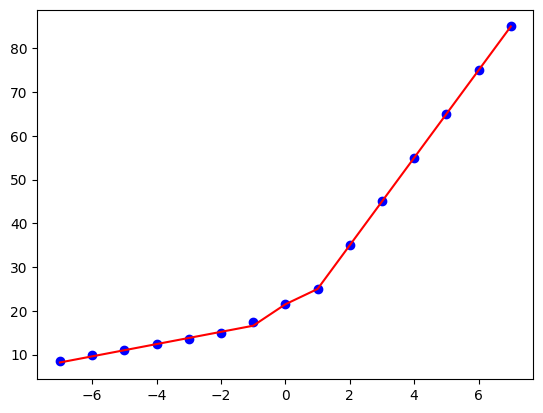

In [128]:
plt.plot(band, delta, 'bo', label='raw')
plt.plot(band, delta_model, 'r-', label='computed')

It looks like the $\Delta P$ value for $B = 0$ should not be 21.5. Perhaps (15+18)/2 might be better.


## Computing $\Delta P$ from Piety, $P$

The idea here is to folding in the band computation into the $\Delta P$ computation. This *might* be simpler because it cuts out the band computation step.

In [131]:
def delta_P_P(piety: int, magnitude: int):
    if piety < 0:
        band = -(sqrt(20*abs(piety) + 425)/10 - 3/2)
        delta_1 = band * 1.4 + 18
    elif piety > 0:
        band = (sqrt(20*abs(piety) + 425)/10 - 3/2)
        delta_1 = band * 10 + 15
    else:
        delta_1 = 21.5
    return delta_1 / magnitude

In [132]:
piety = lambda b: 5*b*b+15*b-10 if b >= 0 else -5*b*b+15*b-10

delta_model_2 = [delta_P_P(piety(b), 1) for b in band]

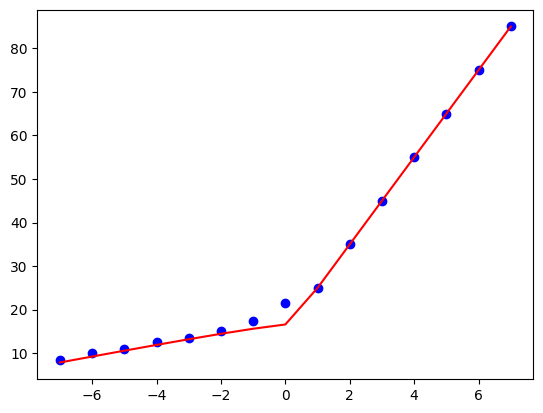

In [133]:
plt.plot(band, delta, 'bo', label='raw')
plt.plot(band, delta_model_2, 'r-', label='computed')

Here are the combined computations. They're not simpler. There's no real benefit of doing the computations from piety directly.

In [134]:
B, P, M = symbols('B, P, M')
-(sqrt(20*abs(P) + 425)/10 - 3/2) * 1.4 + 18

20.1 - 0.14*sqrt(20*Abs(P) + 425)

In [135]:
(sqrt(20*abs(P) + 425)/10 - 3/2) * 10 + 15

sqrt(20*Abs(P) + 425)

## Game Scenarios

The large values of $\Delta P = \frac{10B + 15}{M}$ are used for reversals in piety, turns back toward zero. These are described above as (1b),  very pious character's unexpected sin, and (2b), an impious character's odd virtuous act.

At the other end, the small values of $\Delta P = \frac{18 - 1.4B}{M}$ are used to continue extending the character's piety away from zero. These are described above as (1a), a pious character's virtuous act, and (1b), another sin by an impious character.

Example.

Start at zero piety. Do small things of magnitude 5 ("Bravery, Loyalty, Magnanimity"). The increase factor drops, meaning more and more of those things must be done to increase the piety band.

In [137]:
print("event, Piety Band, Piety")
magnitude = 5
p = 0
for i in range(30):
    band = int((sqrt(20*p + 425)/10 - 3/2).evalf())
    change = int((18 - 1.4*band) / magnitude)
    p += change
    print(i, band, p)

event, Piety Band, Piety
0 0 3
1 0 6
2 0 9
3 0 12
4 1 15
5 1 18
6 1 21
7 1 24
8 1 27
9 1 30
10 1 33
11 1 36
12 1 39
13 1 42
14 2 45
15 2 48
16 2 51
17 2 54
18 2 57
19 2 60
20 2 63
21 2 66
22 2 69
23 2 72
24 2 75
25 2 78
26 2 81
27 3 83
28 3 85
29 3 87


A useful question is "how many steps to the next level?"
There are, of course, two directions of travel -- away from zero and a reversal toward zero.

Away from zero is taken in small steps.

A reverssal toward zero is taken in large steps.

In [138]:
B = symbols('B')

rev = ((5*(B+1)**2-15*(B+1)+10)-(5*B**2-15*B+10))/(B*10+15); rev

(-5*B**2 + 5*(B + 1)**2 - 15)/(10*B + 15)

In [139]:
fwd = ((5*(B+1)**2-15*(B+1)+10)-(5*B**2-15*B+10))/(18-1.4*B); fwd

(-5*B**2 + 5*(B + 1)**2 - 15)/(18 - 1.4*B)

In [162]:
print("Magnitude = 1, others have smaller step sizes")
print("PB, Piety, Reversal, Forward")
for i in range(1, 8):
    piety = 5*i**2+15*i-10
    rev_step_size = 10*i+15   # * (1/m)
    fwd_step_size = 18-1.4*i  # * (1/m)
    print(f"{i}, {piety}, {piety / rev_step_size:.1f}, {piety / fwd_step_size:.1f}")

Magnitude = 1, others have smaller step sizes
PB, Piety, Reversal, Forward
1, 10, 0.4, 0.6
2, 40, 1.1, 2.6
3, 80, 1.8, 5.8
4, 130, 2.4, 10.5
5, 190, 2.9, 17.3
6, 260, 3.5, 27.1
7, 340, 4.0, 41.5


In [161]:
for i in range(1, 8):
    fw_piety = 5*i**2+15*i-10
    d6_piety = int(fw_piety/10) * 3
    dice, pips = divmod(d6_piety, 3)
    print(d6_piety, f"{dice}D+{pips}")

3 1D+0
12 4D+0
24 8D+0
39 13D+0
57 19D+0
78 26D+0
102 34D+0


## Goal: Apply FW idea to Open D6

The essential Piety Band = Open D6 Rank = Dice bonus (1D to 7D) seems to adapt nicely between FW and OpenD6.

The piety point mechanic, however, doesn't fit with OpenD6.
There are two reasons, both closely related:

1. Most OpenD6 skills and abilities enjoy linear growth. Body and Magic Fatigue, for example, are linear. Most ranks are linear. The FW system relies on polynomial growth to make it more difficult for high-ranking characters to advance further.
2. Additionally, in the places where OpenD6 is non-linear, growth tends to be exponential. The $5\log_{10}m$ rule is ubiquitous to defining difficulties. This makes high-ranking characters more powerful.

The FW exponential growth model is based on the idea of fixed experience point rewards. The experience is equal to the hit points of defeated enemies and the value of acquired treasure. Characters need to move to more difficult monsters and larger piles of treasure to continue to grow.

The OpenD6 linear growth model is based on the idea of experience point awards predicated on the level of challenge. Low-ranked characters might get more points for an encounter than high-ranked characters.

(See "Adventure Tips: Rewarding the Characters" for the scale of the difficulties overcome.)

## Suggested Design

These rules should use an accumulator (like Character Points) for pious and impious actions. The scale would use pips (instead of whole die). An FW-based feature that is interesting would be to use small gains and large losses. Actions which align with the temple lead to small gains  of 1-2 pips; actions that fail to align might be a 3 to 6 pip loss.

This also means the sign complication would be removed.
There aren't two diametrically-opposed temples: there are six.

This means the fixed list of magnitudes from 1-7 covering the spectrum of actions from murder to undignified conduct would be removed. The GM would award based on difficulty, temptations to stray from the temple's doctrines, and skills used. All more-of-the-same action would have declining piety point consequences.
Any course reversals, of course, would have large piety point consequences.

# Appendices

## Curve Fitting using Numbers

These use Piety directly, skipping the band computation.
They are too complicated for a book written in 1982.
Eliminating the band computation, these suggest a Sigmoid $y = \frac{1}{1+e^{-x}}$, which seems unlikely.

In [142]:
(95*ln(P+360)  - 539)*(1/M)

(95*log(P + 360) - 539)/M

In [143]:
 8 * exp(.0023 * (P+361))*(1/M)

18.3520547127674*exp(0.0023*P)/M